In [4]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df['TotalCharges'].apply(lambda x: x.strip() == '').sum()

np.int64(11)

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [9]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [10]:
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [11]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [12]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [13]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

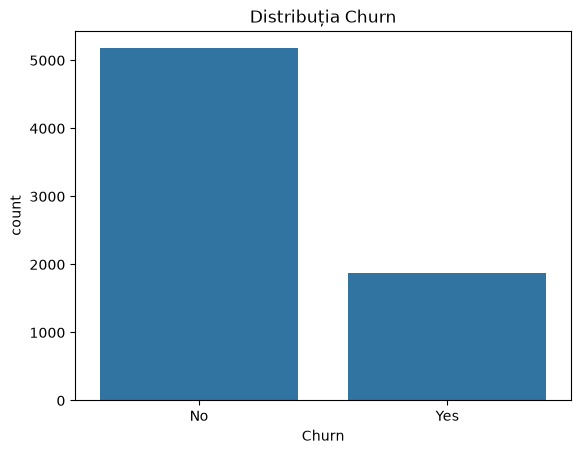

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='Churn')
plt.title('Distribuția Churn')
plt.show()

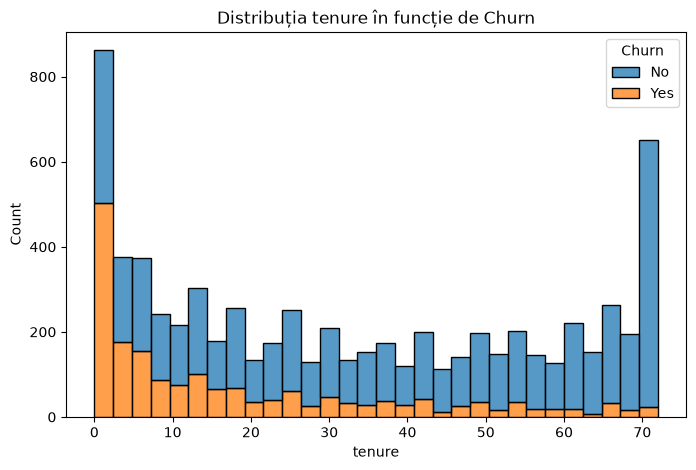

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Distribuția tenure în funcție de Churn')
plt.show()

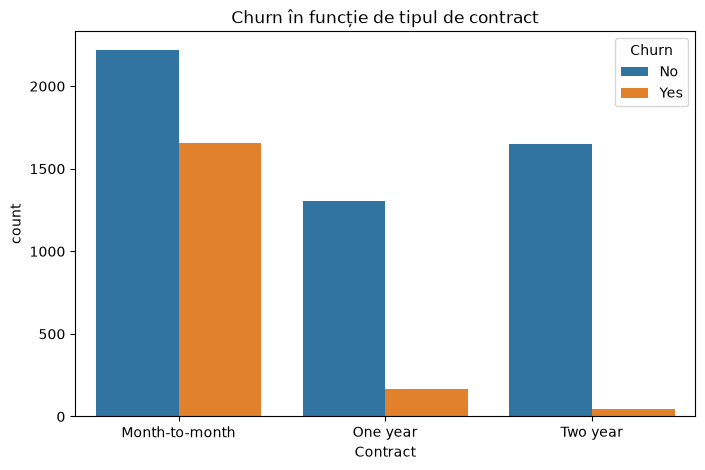

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn în funcție de tipul de contract')
plt.show()

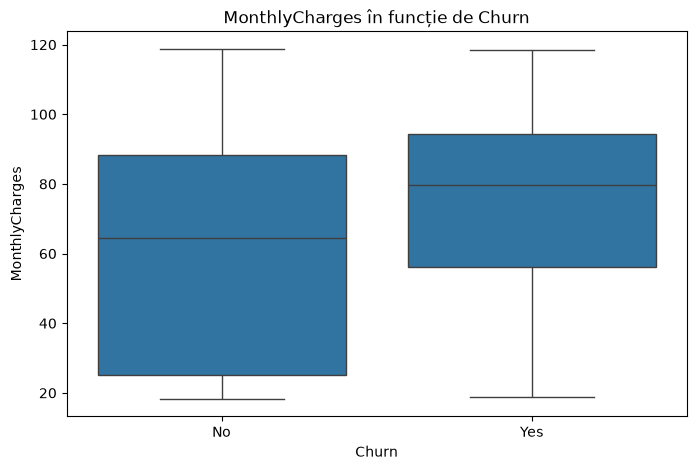

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('MonthlyCharges în funcție de Churn')
plt.show()

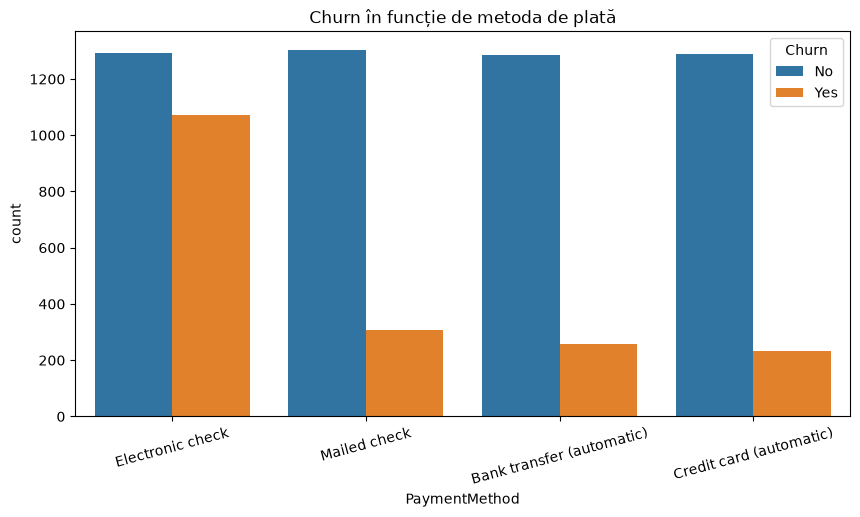

In [19]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title('Churn în funcție de metoda de plată')
plt.xticks(rotation=15)
plt.show()

In [20]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')
categorical_cols.remove('Churn')

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df.groupby(col)['Churn'].value_counts(normalize=True).unstack() * 100)


--- gender ---
Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338

--- Partner ---
Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903

--- Dependents ---
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237

--- PhoneService ---
Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637

--- MultipleLines ---
Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896

--- InternetService ---
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.59

/var/folders/8r/bw1b1sgd3qj2z9hg1t85v9vw0000gn/T/ipykernel_92281/3100080215.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


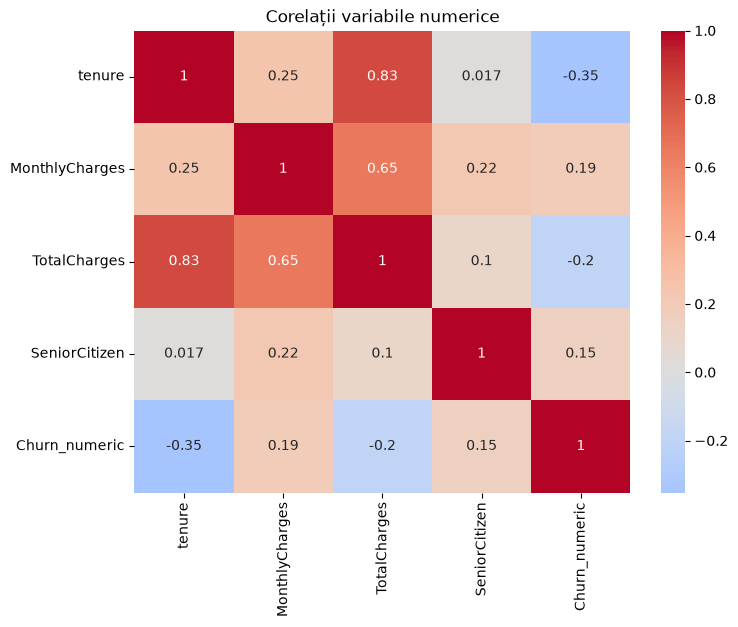

In [21]:
df['Churn_numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_numeric']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Corelații variabile numerice')
plt.show()

In [22]:
for col in ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract']:
    print(f"\n--- {col} ---")
    print(df.groupby(col)['Churn'].value_counts(normalize=True).unstack() * 100)


--- InternetService ---
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980

--- OnlineSecurity ---
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194

--- OnlineBackup ---
Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494

--- DeviceProtection ---
Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064

--- TechSupport ---
Churn                       No        Yes
TechSupport         

In [23]:
df_model = df.drop(['customerID', 'Churn_numeric'], axis=1)

In [24]:
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

In [25]:
df_model = pd.get_dummies(df_model, drop_first=True)

In [26]:
df_model.head()
df_model.shape

(7043, 31)

In [27]:
from sklearn.model_selection import train_test_split

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
X_train.shape, X_test.shape

((5634, 30), (1409, 30))

In [29]:
from sklearn.preprocessing import StandardScaler

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [30]:
X_train[numeric_features].describe()

,tenure,MonthlyCharges,TotalCharges
count,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,-2.402527e-16,2.522338e-17
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.544028e+00,-1.008922e+00
25%,-9.559779e-01,-9.711977e-01,-8.321009e-01
50%,-1.418632e-01,1.848336e-01,-3.968446e-01
75%,9.164859e-01,8.319124e-01,6.741944e-01
max,1.608483e+00,1.785939e+00,2.801869e+00


In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [32]:
coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
})
coefficients = coefficients.sort_values('coefficient', ascending=False)
coefficients

,feature,coefficient
10,InternetService_Fiber optic,1.180666
3,TotalCharges,0.527772
28,PaymentMethod_Electronic check,0.392775
21,StreamingTV_Yes,0.374831
26,PaperlessBilling_Yes,0.374218
23,StreamingMovies_Yes,0.373193
9,MultipleLines_Yes,0.361646
0,SeniorCitizen,0.147911
29,PaymentMethod_Mailed check,0.081866
17,DeviceProtection_Yes,0.033106


In [34]:
df_model_v2 = df.drop(['customerID', 'Churn_numeric', 'TotalCharges'], axis=1)
df_model_v2['Churn'] = df_model_v2['Churn'].map({'Yes': 1, 'No': 0})
df_model_v2 = pd.get_dummies(df_model_v2, drop_first=True)

X2 = df_model_v2.drop('Churn', axis=1)
y2 = df_model_v2['Churn']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

numeric_features_v2 = ['tenure', 'MonthlyCharges']
scaler_v2 = StandardScaler()
X2_train[numeric_features_v2] = scaler_v2.fit_transform(X2_train[numeric_features_v2])
X2_test[numeric_features_v2] = scaler_v2.transform(X2_test[numeric_features_v2])

In [35]:
model_v2 = LogisticRegression(max_iter=1000, random_state=42)
model_v2.fit(X2_train, y2_train)

coefficients_v2 = pd.DataFrame({
    'feature': X2_train.columns,
    'coefficient': model_v2.coef_[0]
})
coefficients_v2 = coefficients_v2.sort_values('coefficient', ascending=False)
coefficients_v2

,feature,coefficient
9,InternetService_Fiber optic,1.227531
22,StreamingMovies_Yes,0.402917
20,StreamingTV_Yes,0.402648
8,MultipleLines_Yes,0.388405
27,PaymentMethod_Electronic check,0.380162
25,PaperlessBilling_Yes,0.363291
0,SeniorCitizen,0.140692
28,PaymentMethod_Mailed check,0.102204
16,DeviceProtection_Yes,0.060503
3,gender_Male,0.024416


In [36]:
y2_pred = model_v2.predict(X2_test)

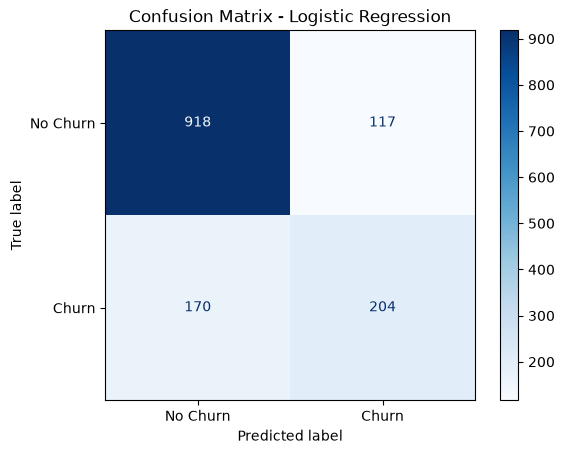

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y2_test, y2_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y2_test, y2_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [39]:
model_v3 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_v3.fit(X2_train, y2_train)

y2_pred_balanced = model_v3.predict(X2_test)

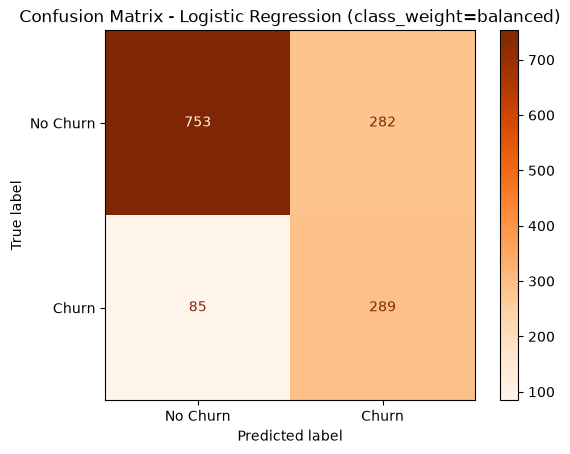

              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.80      1035
       Churn       0.51      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409



In [40]:
cm_balanced = confusion_matrix(y2_test, y2_pred_balanced)
disp_balanced = ConfusionMatrixDisplay(confusion_matrix=cm_balanced, display_labels=['No Churn', 'Churn'])
disp_balanced.plot(cmap='Oranges')
plt.title('Confusion Matrix - Logistic Regression (class_weight=balanced)')
plt.show()

print(classification_report(y2_test, y2_pred_balanced, target_names=['No Churn', 'Churn']))

In [41]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_rf.fit(X2_train, y2_train)

y2_pred_rf = model_rf.predict(X2_test)

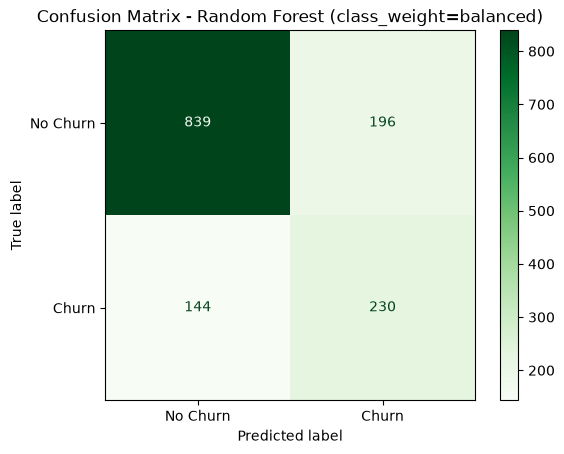

              precision    recall  f1-score   support

    No Churn       0.85      0.81      0.83      1035
       Churn       0.54      0.61      0.57       374

    accuracy                           0.76      1409
   macro avg       0.70      0.71      0.70      1409
weighted avg       0.77      0.76      0.76      1409



In [42]:
cm_rf = confusion_matrix(y2_test, y2_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Churn', 'Churn'])
disp_rf.plot(cmap='Greens')
plt.title('Confusion Matrix - Random Forest (class_weight=balanced)')
plt.show()

print(classification_report(y2_test, y2_pred_rf, target_names=['No Churn', 'Churn']))